In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from vizman import viz

base_dir = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm")
distance_measure = "energy" # "hamming" # delta_con
distance_name_in_csv_dict = {
    "hamming": "HammingDist", 
    "delta_con": "DeltaCon", 
    "energy": "MaxCrit"
}
distance_name_in_csv = distance_name_in_csv_dict[distance_measure]

csv_files = {
    'humans': base_dir / f"hcp_schaefer_100_dataset/05_mst_animal_0_compared_with_hcp_schaefer_100/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_hcp_schaefer_100.csv",
    'diffusion': base_dir / f"kaysons_generated_networks_diffusion/05_mst_animal_0_compared_with_diffusion/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_diffusion.csv",
    'propagation': base_dir / f"kaysons_generated_networks_propagation/05_mst_animal_0_compared_with_propagation/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_propagation.csv",
    'routing': base_dir / f"kaysons_generated_networks_routing/05_mst_animal_0_compared_with_routing/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_routing.csv",
    'mami': base_dir / f"suarez_MaMI_dataset/05_mst_animal_0_compared_with_mami/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_mami.csv"
}


Processing humans...
104
  Found 100 minima
Processing diffusion...
5
  Found 1 minima
Processing propagation...
5
  Found 1 minima
Processing routing...
5
  Found 1 minima
Processing mami...
228
  Found 224 minima


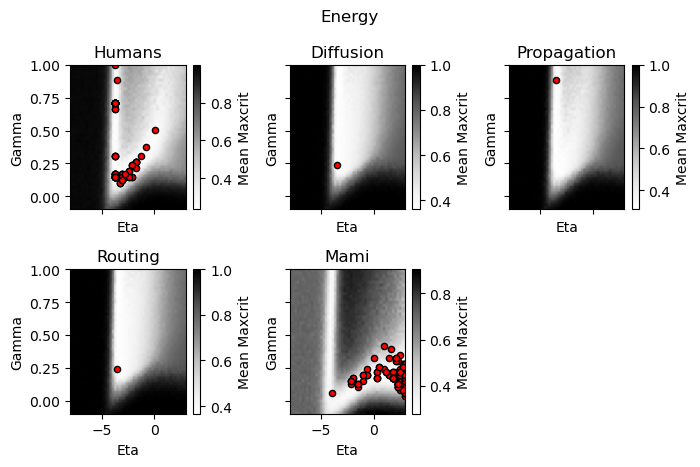

In [4]:

# Store all minima for each network type
all_minima = {}

# Do this in subplots
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=viz.cm_to_inch((18,12)), sharex=True, sharey=True, dpi=100)
axs = axs.flatten()

# Process each CSV file
for i, (network_name, csv_path) in enumerate(csv_files.items()):
    print(f"Processing {network_name}...")
    
    # Load the data
    df = pd.read_csv(csv_path)
    
    # Remove all "_x" and "_y" etc from the keys, and remove then all columns that have already appeared (exactly do this for "_x", "_y", "_z")
    # unique_keys = list(set([k.replace("_x", "").replace("_y", "").replace("_z", "")+"_x" for k in df.keys()]) - set(['eta_x', 'filename_x', 'id_x', 'gamma_x', 'network_index_x']))
    # unique_keys = unique_keys + ['eta', 'filename', 'id', 'gamma', 'network_index']
    # df = df[unique_keys]
    keys = set([k.replace("_x", "").replace("_y", "").replace("_z", "") for k in df.keys()])
    keys = keys - set(['eta', 'filename', 'id', 'gamma', 'network_index'])
    unique_keys = list(keys)
    unique_keys

    all_keys = set(df.keys())
    # Get the first column-name version for each unique key (e.g. "eta_x" for "eta", "gamma_x" for "gamma", etc.)
    first_versions = []
    for key in unique_keys:
        for suffix in ["", "_x", "_y", "_z"]:
            candidate = key + suffix
            if candidate in all_keys:
                first_versions.append(candidate)
                break

    # print(len(first_versions), len(df.columns))

    df = df[first_versions + ['eta', 'id', 'gamma', 'network_index']] # 'filename', 
    
    # # Drop filename column if it exists
    # if 'filename' in df.columns:
    #     df.drop(columns=["filename"], inplace=True)
    
    print(len(df.keys()))
    
    # Group by eta and gamma and calculate mean
    df_mean = df.groupby(["eta", "gamma"]).mean().reset_index()
    
    # Find minima for each subject (DeltaCon columns)
    distance_measure_columns = [col for col in df_mean.columns if f"{distance_name_in_csv}_subject_" in col]

    df_mean[f"{distance_name_in_csv}_mean"] = df_mean[distance_measure_columns].mean(axis=1)

    minima_eta = []
    minima_gamma = []
    number_minima = []

    for col in distance_measure_columns:
        # Find the row with minimum DeltaCon for this subject
        min_idx = df_mean[col].idxmin()
        minima_eta.append(df_mean.loc[min_idx, "eta"])
        minima_gamma.append(df_mean.loc[min_idx, "gamma"])
        # Add the number of minimum values to an array 
        # number_minima.append(df_mean.loc[min_idx, "gamma"].to_numpy())
        # print(np.array(df_mean.loc[min_idx, "gamma"]).shape)

    all_minima[network_name] = {
        'eta': minima_eta,
        'gamma': minima_gamma,
        'df_mean': df_mean, 
        'number_minima': number_minima
    }
    print(f"  Found {len(minima_eta)} minima")
    
    cmap = "Grays"

    # CHANGE SCALING HERE: EITHER FROM 300 to 2300, or for every plot individually. 
    background = axs[i].imshow(df_mean.pivot(index="gamma", columns="eta", values=f"{distance_name_in_csv}_mean"), 
                               extent=(df_mean["eta"].min(), df_mean["eta"].max(), df_mean["gamma"].min(), df_mean["gamma"].max()), 
                               origin='lower', aspect='auto', cmap=cmap) # , vmin=300, vmax=2300) # , alpha=0.5)
    
    
    axs[i].set_title(network_name.capitalize())
    axs[i].set_xlabel("Eta")
    axs[i].set_ylabel("Gamma") 
    plt.colorbar(background, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")

    # Add minima points
    axs[i].scatter(minima_eta, minima_gamma, color='red', s=20, label='Minima', edgecolor='black')
    # ax_min = axs[i].scatter(minima_eta, minima_gamma, c=number_minima, s=20, label='Minima', edgecolor='black', cmap="Reds")
    # axs[i].legend()
    
    
    # Add colorbar
    # norm = plt.Normalize(df_mean[f"{distance_name_in_csv}_mean"].min(), df_mean[f"{distance_name_in_csv}_mean"].max())
    # norm = plt.Normalize(300, 2300) # df_mean[f"{distance_name_in_csv}_mean"].min(), df_mean[f"{distance_name_in_csv}_mean"].max())
    # sm = plt.cm.ScalarMappable(cmap=cmap) # , norm=norm)
    # sm.set_array([])
    # fig.colorbar(sm, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")
    # plt.colorbar(ax_min, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")

# Remove empty subplot
if len(csv_files) < len(axs):
    for j in range(len(csv_files), len(axs)):
        fig.delaxes(axs[j])

plt.suptitle(f"{distance_measure.capitalize()}") # .replace(" ", "")}")
plt.tight_layout()

Processing humans...
104
  Found 100 minima
Processing diffusion...
5
  Found 1 minima
Processing propagation...
5
  Found 1 minima
Processing routing...
5
  Found 1 minima
Processing mami...
228
  Found 224 minima


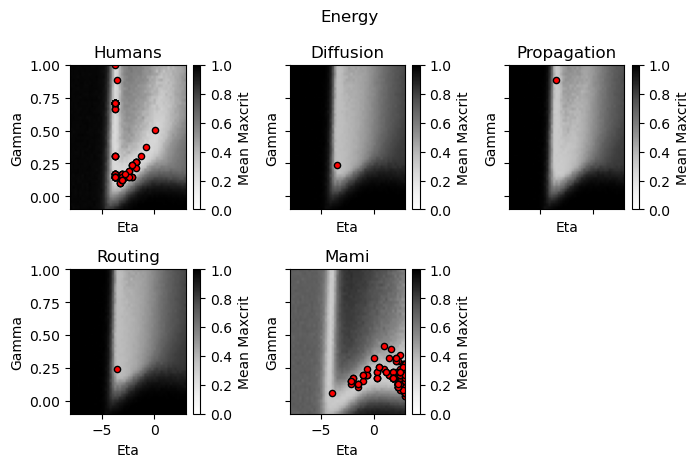

In [7]:

# Store all minima for each network type
all_minima = {}

# Do this in subplots
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=viz.cm_to_inch((18,12)), sharex=True, sharey=True, dpi=100)
axs = axs.flatten()

# Process each CSV file
for i, (network_name, csv_path) in enumerate(csv_files.items()):
    print(f"Processing {network_name}...")
    
    # Load the data
    df = pd.read_csv(csv_path)
    
    # Remove all "_x" and "_y" etc from the keys, and remove then all columns that have already appeared (exactly do this for "_x", "_y", "_z")
    # unique_keys = list(set([k.replace("_x", "").replace("_y", "").replace("_z", "")+"_x" for k in df.keys()]) - set(['eta_x', 'filename_x', 'id_x', 'gamma_x', 'network_index_x']))
    # unique_keys = unique_keys + ['eta', 'filename', 'id', 'gamma', 'network_index']
    # df = df[unique_keys]
    keys = set([k.replace("_x", "").replace("_y", "").replace("_z", "") for k in df.keys()])
    keys = keys - set(['eta', 'filename', 'id', 'gamma', 'network_index'])
    unique_keys = list(keys)
    unique_keys

    all_keys = set(df.keys())
    # Get the first column-name version for each unique key (e.g. "eta_x" for "eta", "gamma_x" for "gamma", etc.)
    first_versions = []
    for key in unique_keys:
        for suffix in ["", "_x", "_y", "_z"]:
            candidate = key + suffix
            if candidate in all_keys:
                first_versions.append(candidate)
                break

    # print(len(first_versions), len(df.columns))

    df = df[first_versions + ['eta', 'id', 'gamma', 'network_index']] # 'filename', 
    
    # # Drop filename column if it exists
    # if 'filename' in df.columns:
    #     df.drop(columns=["filename"], inplace=True)
    
    print(len(df.keys()))
    
    # Group by eta and gamma and calculate mean
    df_mean = df.groupby(["eta", "gamma"]).mean().reset_index()
    
    # Find minima for each subject (DeltaCon columns)
    distance_measure_columns = [col for col in df_mean.columns if f"{distance_name_in_csv}_subject_" in col]

    df_mean[f"{distance_name_in_csv}_mean"] = df_mean[distance_measure_columns].mean(axis=1)

    minima_eta = []
    minima_gamma = []
    number_minima = []

    for col in distance_measure_columns:
        # Find the row with minimum DeltaCon for this subject
        min_idx = df_mean[col].idxmin()
        minima_eta.append(df_mean.loc[min_idx, "eta"])
        minima_gamma.append(df_mean.loc[min_idx, "gamma"])
        # Add the number of minimum values to an array 
        # number_minima.append(df_mean.loc[min_idx, "gamma"].to_numpy())
        # print(np.array(df_mean.loc[min_idx, "gamma"]).shape)

    all_minima[network_name] = {
        'eta': minima_eta,
        'gamma': minima_gamma,
        'df_mean': df_mean, 
        'number_minima': number_minima
    }
    print(f"  Found {len(minima_eta)} minima")
    
    cmap = "Grays"

    # CHANGE SCALING HERE: EITHER FROM 300 to 2300, or for every plot individually. 
    if distance_measure == "delta_con": 
        vmin = 4
        vmax = 12 
    elif distance_measure == "hamming":
        vmin = 300
        vmax = 2300
    elif distance_measure == "energy":
        vmin = 0
        vmax = 1
    background = axs[i].imshow(df_mean.pivot(index="gamma", columns="eta", values=f"{distance_name_in_csv}_mean"), 
                               extent=(df_mean["eta"].min(), df_mean["eta"].max(), df_mean["gamma"].min(), df_mean["gamma"].max()), 
                               origin='lower', aspect='auto', cmap=cmap,
                               vmin=vmin, vmax=vmax) # , alpha=0.5)


    axs[i].set_title(network_name.capitalize())
    axs[i].set_xlabel("Eta")
    axs[i].set_ylabel("Gamma") 
    plt.colorbar(background, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")

    # Add minima points
    axs[i].scatter(minima_eta, minima_gamma, color='red', s=20, label='Minima', edgecolor='black')
    # ax_min = axs[i].scatter(minima_eta, minima_gamma, c=number_minima, s=20, label='Minima', edgecolor='black', cmap="Reds")
    # axs[i].legend()
    
    
    # Add colorbar
    # norm = plt.Normalize(df_mean[f"{distance_name_in_csv}_mean"].min(), df_mean[f"{distance_name_in_csv}_mean"].max())
    # norm = plt.Normalize(300, 2300) # df_mean[f"{distance_name_in_csv}_mean"].min(), df_mean[f"{distance_name_in_csv}_mean"].max())
    # sm = plt.cm.ScalarMappable(cmap=cmap) # , norm=norm)
    # sm.set_array([])
    # fig.colorbar(sm, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")
    # plt.colorbar(ax_min, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")

# Remove empty subplot
if len(csv_files) < len(axs):
    for j in range(len(csv_files), len(axs)):
        fig.delaxes(axs[j])

plt.suptitle(f"{distance_measure.capitalize()}")
plt.tight_layout()

In [ ]:
df_mean.loc[min_idx]

eta                           -2.836735
gamma                          0.932653
HammingDist_subject_77      2864.600000
HammingDist_subject_140     1917.400000
HammingDist_subject_149     2272.200000
                               ...     
HammingDist_subject_85      2047.400000
HammingDist_subject_62      2245.200000
id                             4.500000
network_index              12882.600000
HammingDist_mean            2167.127111
Name: 1196, Length: 230, dtype: float64

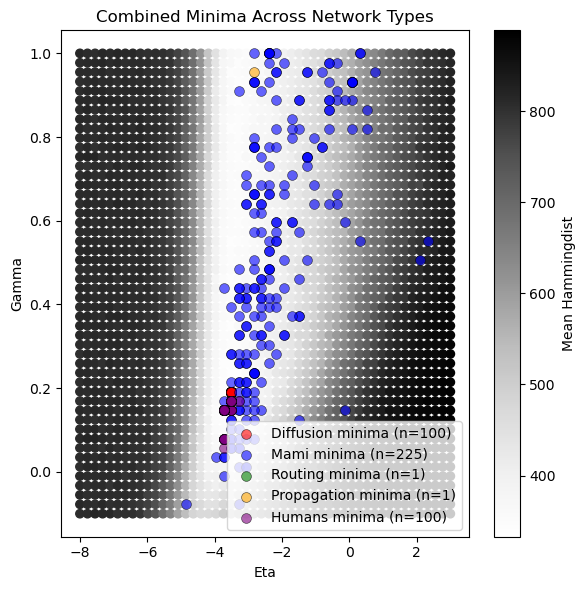


SUMMARY STATISTICS

DIFFUSION:
  Eta range: [-3.510, -3.510]
  Gamma range: [0.192, 0.192]
  Eta mean ± std: -3.510 ± 0.000
  Gamma mean ± std: 0.192 ± 0.000

MAMI:
  Eta range: [-4.857, 2.327]
  Gamma range: [-0.078, 1.000]
  Eta mean ± std: -2.231 ± 1.175
  Gamma mean ± std: 0.525 ± 0.304

ROUTING:
  Eta range: [-3.510, -3.510]
  Gamma range: [0.169, 0.169]
  Eta mean ± std: -3.510 ± 0.000
  Gamma mean ± std: 0.169 ± 0.000

PROPAGATION:
  Eta range: [-2.837, -2.837]
  Gamma range: [0.955, 0.955]
  Eta mean ± std: -2.837 ± 0.000
  Gamma mean ± std: 0.955 ± 0.000

HUMANS:
  Eta range: [-3.735, -3.286]
  Gamma range: [0.057, 0.169]
  Eta mean ± std: -3.665 ± 0.109
  Gamma mean ± std: 0.146 ± 0.024


In [ ]:

# Create the combined plot
plt.figure(figsize=(6,6), dpi=100)

# Define colors for each network type
colors = {
    'diffusion': 'red',
    'mami': 'blue',
    'routing': 'green', 
    'propagation': 'orange',
    'humans': 'purple'
}

cmap = "Grays"

# Plot the landscape from one network (they should be similar)
# Using diffusion as the base
base_network = 'diffusion'
df_mean = all_minima[base_network]['df_mean']
if f"{distance_name_in_csv}_mean" not in df_mean.columns:
    # Calculate mean across all subjects
    distance_measure_columns = [col for col in df_mean.columns if f"{distance_name_in_csv}_subject_" in col]
    df_mean[f"{distance_name_in_csv}_mean"] = df_mean[distance_measure_columns].mean(axis=1)

plt.scatter(df_mean["eta"], df_mean["gamma"], c=df_mean[f"{distance_name_in_csv}_mean"], 
            cmap=cmap) # , # alpha=0.3, s=30, label='Landscape (mean DeltaCon)')

# Add colorbar for the landscape
plt.colorbar(label=f'Mean {distance_name_in_csv.capitalize()}')

# Plot minima for each network type
for network_name, color in colors.items():
    minima = all_minima[network_name]
    plt.scatter(minima['eta'], minima['gamma'], 
                c=color, marker='o', s=50, alpha=0.6, 
                label=f'{network_name.capitalize()} minima (n={len(minima["eta"])})',
                edgecolors='black', linewidths=0.5)

plt.xlabel('Eta')
plt.ylabel('Gamma') 
plt.title('Combined Minima Across Network Types') 
plt.legend(loc='best')
plt.tight_layout()

# Save the figure
output_path = "/home/claude/combined_minima_plot.png"
# plt.savefig(output_path, dpi=150, bbox_inches='tight')
# print(f"\nPlot saved to: {output_path}")
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
for network_name in colors.keys():
    minima = all_minima[network_name]
    print(f"\n{network_name.upper()}:")
    print(f"  Eta range: [{np.min(minima['eta']):.3f}, {np.max(minima['eta']):.3f}]")
    print(f"  Gamma range: [{np.min(minima['gamma']):.3f}, {np.max(minima['gamma']):.3f}]")
    print(f"  Eta mean ± std: {np.mean(minima['eta']):.3f} ± {np.std(minima['eta']):.3f}")
    print(f"  Gamma mean ± std: {np.mean(minima['gamma']):.3f} ± {np.std(minima['gamma']):.3f}")

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_35412/2709138288.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True,


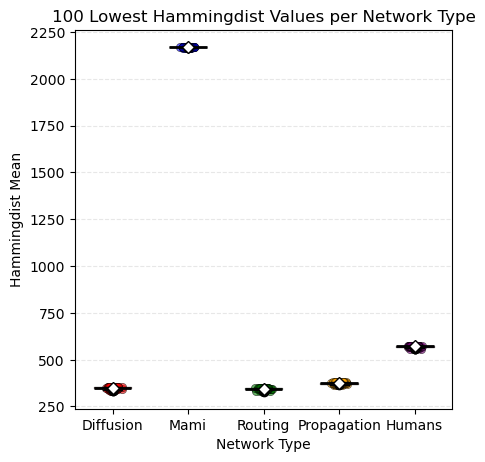


SUMMARY STATISTICS (100 LOWEST VALUES)

DIFFUSION:
  Min: 332.800000
  Q1 (25th percentile): 347.150000
  Median: 350.200000
  Q3 (75th percentile): 353.200000
  Max: 355.600000
  Mean ± std: 349.418000 ± 4.979646

MAMI:
  Min: 2164.302222
  Q1 (25th percentile): 2167.221111
  Median: 2167.773333
  Q3 (75th percentile): 2168.320444
  Max: 2168.744889
  Mean ± std: 2167.701342 ± 0.803474

ROUTING:
  Min: 329.600000
  Q1 (25th percentile): 341.600000
  Median: 344.900000
  Q3 (75th percentile): 347.600000
  Max: 349.800000
  Mean ± std: 343.832000 ± 4.593885

PROPAGATION:
  Min: 362.000000
  Q1 (25th percentile): 371.050000
  Median: 373.900000
  Q3 (75th percentile): 376.650000
  Max: 379.400000
  Mean ± std: 373.490000 ± 3.861023

HUMANS:
  Min: 554.556000
  Q1 (25th percentile): 568.038000
  Median: 570.835000
  Q3 (75th percentile): 573.237000
  Max: 574.978000
  Mean ± std: 569.955420 ± 4.224110


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Collect the 100 lowest DeltaCon values for each network type
boxplot_data = []
labels = []

colors_list = ['red', 'blue', 'green', 'orange', 'purple']
network_types = ['diffusion', 'mami', 'routing', 'propagation', 'humans']

for network_name in network_types:
    df_mean = all_minima[network_name]['df_mean']
    
    # Ensure DeltaCon_mean exists
    if f'{distance_name_in_csv}_mean' not in df_mean.columns:
        distance_measure_columns = [col for col in df_mean.columns if f"{distance_name_in_csv}_subject_" in col]
        df_mean[f'{distance_name_in_csv}_mean'] = df_mean[distance_measure_columns].mean(axis=1)

    # Get the 100 lowest values from the ENTIRE dataframe
    lowest_100 = df_mean[f'{distance_name_in_csv}_mean'].nsmallest(100).values
    boxplot_data.append(lowest_100)
    labels.append(network_name.capitalize())

# Create the boxplot
fig, ax = plt.subplots(figsize=viz.cm_to_inch((12,12)), dpi=100)

bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True,
                showmeans=True, meanline=False,
                medianprops=dict(color='black', linewidth=2),
                meanprops=dict(marker='D', markerfacecolor='white', 
                              markeredgecolor='black', markersize=6))

# Add scatter points for the 100 lowest values
for i, data in enumerate(boxplot_data):
    x = np.random.normal(i + 1, 0.04, size=len(data))  # Jitter the x-values
    ax.scatter(x, data, color=colors_list[i], alpha=0.6, edgecolor='black', linewidth=0.5)

# Color the boxes
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel(f'{distance_name_in_csv.capitalize()} Mean')
ax.set_xlabel('Network Type')
ax.set_title(f'100 Lowest {distance_name_in_csv.capitalize()} Values per Network Type')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print summary statistics for the 100 lowest values
print("\n" + "="*60)
print("SUMMARY STATISTICS (100 LOWEST VALUES)")
print("="*60)
for i, network_name in enumerate(network_types):
    data = boxplot_data[i]
    print(f"\n{network_name.upper()}:")
    print(f"  Min: {np.min(data):.6f}")
    print(f"  Q1 (25th percentile): {np.percentile(data, 25):.6f}")
    print(f"  Median: {np.median(data):.6f}")
    print(f"  Q3 (75th percentile): {np.percentile(data, 75):.6f}")
    print(f"  Max: {np.max(data):.6f}")
    print(f"  Mean ± std: {np.mean(data):.6f} ± {np.std(data):.6f}")